In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/reduced_modi_dataset (1).zip" /content/

In [3]:
!unzip -q "/content/reduced_modi_dataset (1).zip" -d /content/reduced_modi_dataset

In [4]:
import os

for folder in os.listdir("/content/reduced_modi_dataset"):
    print(folder)

reduced_modi_dataset


In [5]:
import os

print(os.listdir("/content/reduced_modi_dataset"))
print(os.listdir("/content/reduced_modi_dataset/reduced_modi_dataset"))

['reduced_modi_dataset']
['digits', 'vowels', 'consonants']


In [6]:
dataset_path = "/content/reduced_modi_dataset/reduced_modi_dataset"

In [7]:
print(os.listdir("/content"))
print(os.listdir("/content/reduced_modi_dataset"))
print(os.listdir("/content/reduced_modi_dataset/reduced_modi_dataset"))

['.config', 'drive', 'reduced_modi_dataset (1).zip', 'reduced_modi_dataset', 'sample_data']
['reduced_modi_dataset']
['digits', 'vowels', 'consonants']


In [8]:
import os
import shutil

base_path = "/content/reduced_modi_dataset/reduced_modi_dataset"

for main_folder in os.listdir(base_path):
    main_path = os.path.join(base_path, main_folder)

    if os.path.isdir(main_path):
        for subfolder in os.listdir(main_path):
            sub_path = os.path.join(main_path, subfolder)

            if os.path.isdir(sub_path):
                shutil.move(sub_path, base_path)

        shutil.rmtree(main_path)

print("Dataset flattened successfully!")

Dataset flattened successfully!


In [9]:
folders = [f for f in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, f))]

print("Total Folders Found:", len(folders))

Total Folders Found: 57


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
dataset_path = "/content/reduced_modi_dataset/reduced_modi_dataset"

In [13]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [42]:
dataset_path = "/content/reduced_modi_dataset/reduced_modi_dataset"

train_dataset = datasets.ImageFolder(dataset_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(dataset_path, transform=val_transforms)

num_classes = len(train_dataset.classes)
print("Total classes:", num_classes)

Total classes: 57


In [43]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, _ = random_split(train_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 68397
Validation size: 17100


In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("Model ready!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Model ready!


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10

In [18]:
train_acc_list = []
val_acc_list = []
train_loss_list = []

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    train_acc_list.append(train_accuracy)
    val_acc_list.append(val_accuracy)
    train_loss_list.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Train Acc: {train_accuracy:.2f}% "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] Loss: 0.4657 Train Acc: 86.14% Val Acc: 91.43%
Epoch [2/10] Loss: 0.2861 Train Acc: 91.23% Val Acc: 93.11%
Epoch [3/10] Loss: 0.2505 Train Acc: 92.18% Val Acc: 93.94%
Epoch [4/10] Loss: 0.2227 Train Acc: 92.93% Val Acc: 93.91%
Epoch [5/10] Loss: 0.2046 Train Acc: 93.42% Val Acc: 94.38%
Epoch [6/10] Loss: 0.1929 Train Acc: 93.67% Val Acc: 93.71%
Epoch [7/10] Loss: 0.1754 Train Acc: 94.26% Val Acc: 95.06%
Epoch [8/10] Loss: 0.1659 Train Acc: 94.51% Val Acc: 94.89%
Epoch [9/10] Loss: 0.1555 Train Acc: 94.74% Val Acc: 95.36%
Epoch [10/10] Loss: 0.1499 Train Acc: 94.89% Val Acc: 95.01%


In [19]:
save_path = "/content/drive/MyDrive/modi_project"
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), save_path + "/resnet18_modi_weights.pth")
torch.save(model, save_path + "/resnet18_modi_full_model.pth")

with open(save_path + "/class_names.json", "w") as f:
    json.dump(train_dataset.dataset.classes, f)

print("Model and class names saved successfully!")

Model and class names saved successfully!


In [26]:
print("Final Training Accuracy: {:.2f}%".format(train_acc_list[-1]))
print("Final Validation Accuracy: {:.2f}%".format(val_acc_list[-1]))

Final Training Accuracy: 94.89%
Final Validation Accuracy: 95.01%


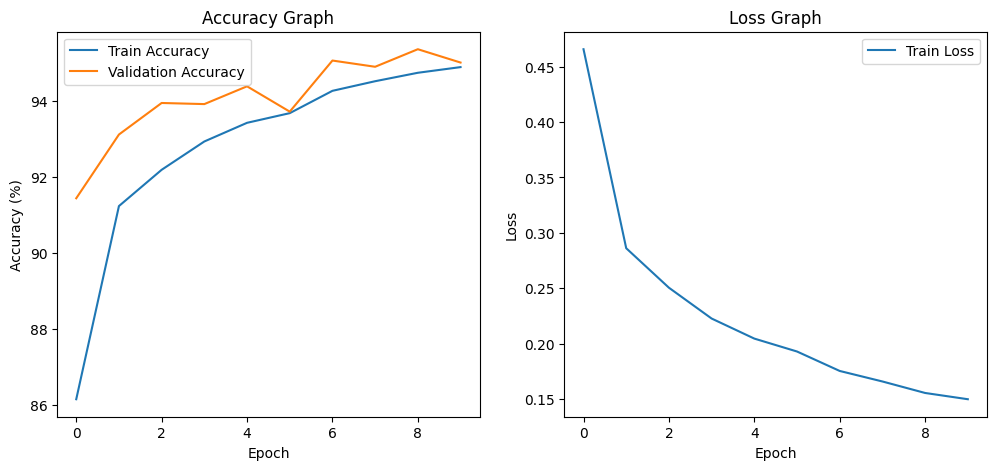

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Graph")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_list, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph")
plt.legend()

plt.show()

In [21]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       314
           1       0.97      0.97      0.97       279
           2       1.00      0.98      0.99       298
           3       0.96      0.97      0.97       279
           4       0.99      0.99      0.99       302
           5       0.94      0.96      0.95       298
           6       0.98      1.00      0.99       311
           7       1.00      0.98      0.99       297
           8       0.96      0.98      0.97       300
           9       0.97      0.86      0.91       278
          10       0.99      0.99      0.99       273
          11       0.98      0.95      0.96       311
          12       1.00      0.99      0.99       280
          13       0.99      0.93      0.96       322
          14       0.99      1.00      0.99       293
          15       1.00      0.75      0.85       322
          16       0.97      0.98      0.97       281
   

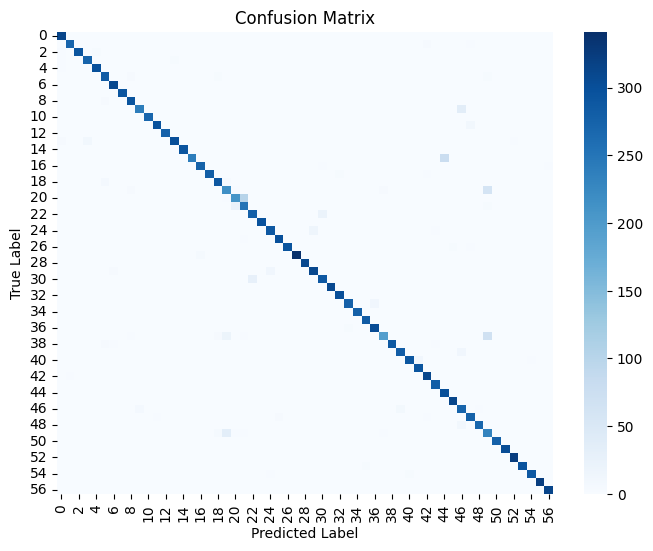

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [27]:
import torch
import torch.nn as nn
import json
from PIL import Image
from torchvision import transforms, models
import os

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [29]:
save_path = "/content/drive/MyDrive/modi_project"

with open(save_path + "/class_names.json", "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)
print("Number of classes:", num_classes)

Number of classes: 57


In [45]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load(save_path + "/resnet18_modi_weights.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [46]:
val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [47]:
modi_to_devanagari = {

    # Vowels
    "a": "अ",
    "aa": "आ",
    "ah": "अः",
    "ai": "ऐ",
    "am": "अं",
    "e": "ए",
    "i": "इ",
    "ii": "ई",
    "o": "ओ",
    "oo": "ऊ",
    "ou": "औ",
    "u": "उ",

    # Consonants
    "b": "ब",
    "bh": "भ",
    "ch": "च",
    "chh": "छ",
    "d": "ड",
    "dh": "ढ",
    "dha": "ध",
    "dyn": "ज्ञ",   # check if correct in your dataset
    "g": "ग",
    "gh": "घ",
    "h": "ह",
    "ja": "ज",
    "jh": "झ",
    "k": "क",
    "kh": "ख",
    "ksh": "क्ष",
    "l": "ल",
    "lh": "ळ",
    "m": "म",
    "n": "न",
    "nn": "ण",
    "p": "प",
    "ph": "फ",
    "r": "र",
    "s": "स",
    "sh": "श",
    "shr": "श्र",
    "ta": "त",
    "th": "थ",
    "tha": "ठ",
    "thh": "थ",
    "thha": "ठ",
    "tr": "त्र",
    "v": "व",
    "y": "य",

    # Digits
    "zero": "०",
    "one": "१",
    "two": "२",
    "three": "३",
    "four": "४",
    "five": "५",
    "six": "६",
    "seven": "७",
    "eight": "८",
    "nine": "९"
}


In [48]:
!apt-get install -y fonts-noto-core

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-core is already the newest version (20201225-1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [49]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Noto Sans Devanagari'

In [50]:
from matplotlib import font_manager

font_path = "/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf"
font_manager.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'Noto Sans Devanagari'

In [51]:
import matplotlib.pyplot as plt
import torch

def show_predictions(num_images=6):

    model.eval()

    images, labels = next(iter(test_loader))

    num_images = min(num_images, len(images))

    plt.figure(figsize=(15,6))

    for i in range(num_images):

        image = images[i]
        label = labels[i]

        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            _, predicted = torch.max(output, 1)

        actual = dataset.classes[label.item()]
        predicted_class = dataset.classes[predicted.item()]

        actual_dev = modi_to_devanagari.get(actual, "")
        predicted_dev = modi_to_devanagari.get(predicted_class, "")

        img = image.cpu().numpy().transpose((1,2,0))
        img = img * 0.5 + 0.5
        img = img.clip(0,1)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A: {actual} ({actual_dev})\nP: {predicted_class} ({predicted_dev})")

    plt.tight_layout()
    plt.show()

show_predictions(6)

NameError: name 'test_loader' is not defined

In [52]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define transforms (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load dataset
dataset = datasets.ImageFolder("/content/reduced_modi_dataset/reduced_modi_dataset", transform=transform)

# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 68397
Test size: 17100


/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 65 (A) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 106 (j) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 104 (h) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 99 (c) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_3998/3609163948.py:40: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Deva

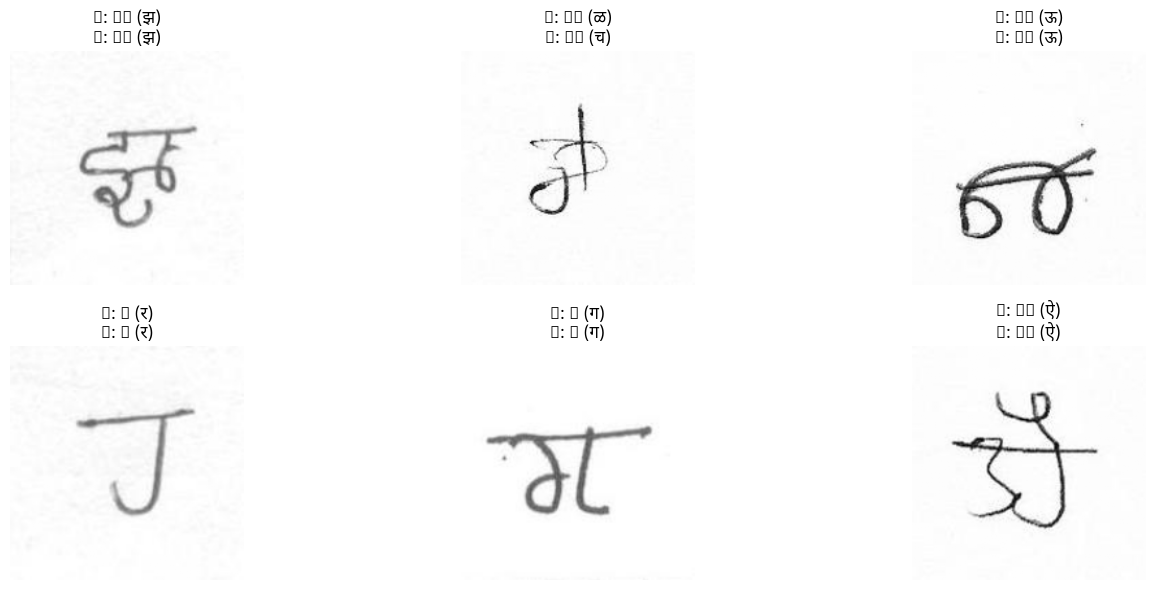

In [53]:
import matplotlib.pyplot as plt
import torch

def show_predictions(num_images=6):

    model.eval()

    images, labels = next(iter(test_loader))

    num_images = min(num_images, len(images))

    plt.figure(figsize=(15,6))

    for i in range(num_images):

        image = images[i]
        label = labels[i]

        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            _, predicted = torch.max(output, 1)

        actual = dataset.classes[label.item()]
        predicted_class = dataset.classes[predicted.item()]

        actual_dev = modi_to_devanagari.get(actual, "")
        predicted_dev = modi_to_devanagari.get(predicted_class, "")

        img = image.cpu().numpy().transpose((1,2,0))
        img = img * 0.5 + 0.5
        img = img.clip(0,1)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A: {actual} ({actual_dev})\nP: {predicted_class} ({predicted_dev})")

    plt.tight_layout()
    plt.show()

show_predictions(6)